<a href="https://colab.research.google.com/github/OuhmadMohamed/DI_Bootcamp/blob/main/Week4/Day4/Mini_Project1_W4_D4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Project:** Data Visualization with Pandas, Seaborn, and Matplotlib

This notebook walks through loading, cleaning, analyzing, and visualizing the Palmer Penguins dataset while providing interpretations for each visualization.


In [3]:
#Data Loading and Cleaning:

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d olgabelitskaya/Palmer_Penguins_Dataset


!unzip Palmer_Penguins_Dataset.zip

Saving Palmer_Penguins_Dataset.zip to Palmer_Penguins_Dataset.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
Archive:  Palmer_Penguins_Dataset.zip
  inflating: Palmer Penguins Dataset.csv  


1. Import Libraries

In [4]:

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# Improve plot appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Display all columns
pd.set_option("display.max_columns", None)

2. Load the Dataset

In [5]:
# Load dataset
penguins = pd.read_csv("Palmer Penguins Dataset.csv")

# First rows
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


3. Inspect the Dataset

In [6]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [7]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [9]:
penguins.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


4. Data Cleaning


In [10]:
#Check Missing Values

penguins.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


In [11]:
#Remove Missing Rows
penguins = penguins.dropna()

In [12]:
#Verify
penguins.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0
year,0


In [13]:
#Check Data Types
penguins.dtypes

,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
year,int64


5. Exploratory Data Analysis (EDA)

In [14]:
#Summary Statistics
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,5.468668,1.969235,14.015765,805.215802,0.812944
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [15]:
#Unique Values
for col in penguins.columns:
    print(f"\n{col}")
    print(penguins[col].unique())


species
['Adelie' 'Gentoo' 'Chinstrap']

island
['Torgersen' 'Biscoe' 'Dream']

bill_length_mm
[39.1 39.5 40.3 36.7 39.3 38.9 39.2 41.1 38.6 34.6 36.6 38.7 42.5 34.4
 46.  37.8 37.7 35.9 38.2 38.8 35.3 40.6 40.5 37.9 37.2 40.9 36.4 42.2
 37.6 39.8 36.5 40.8 36.  44.1 37.  39.6 42.3 40.1 35.  42.  34.5 41.4
 39.  35.7 41.3 41.6 35.5 41.8 33.5 39.7 45.8 42.8 36.2 42.1 42.9 35.1
 37.3 36.3 36.9 38.3 34.  38.1 33.1 43.2 41.  45.6 42.7 40.2 35.2 41.5
 38.5 43.1 36.8 37.5 35.6 32.1 40.7 46.1 50.  48.7 47.6 46.5 45.4 46.7
 43.3 46.8 49.  45.5 48.4 49.3 49.2 46.2 50.2 45.1 46.3 47.8 48.2 47.3
 59.6 49.1 42.6 44.4 44.  49.6 45.3 50.5 43.6 44.9 45.2 46.6 48.5 50.1
 45.  43.8 50.4 45.7 54.3 49.8 49.5 43.5 50.7 47.7 46.4 48.6 47.5 51.1
 52.5 47.4 50.8 43.4 51.3 52.1 52.2 44.5 49.4 46.9 55.9 47.2 41.7 53.4
 48.1 51.5 55.1 48.8 49.9 52.7 51.7 47.  52.  45.9 50.3 58.  42.4 50.6
 52.8 54.2 51.  49.7 53.5 50.9 51.4 51.9 55.8]

bill_depth_mm
[18.7 17.4 18.  19.3 20.6 17.8 19.6 17.6 21.2 21.1 19.  20.7 

In [16]:
#Species Counts
penguins["species"].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


In [17]:
#Island Counts
penguins["island"].value_counts()

,count
island,
Biscoe,163
Dream,123
Torgersen,47


In [18]:
#Sex Counts
penguins["sex"].value_counts()

,count
sex,
male,168
female,165


6. Species Distribution (Bar Chart)

/tmp/ipykernel_17987/4104171992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


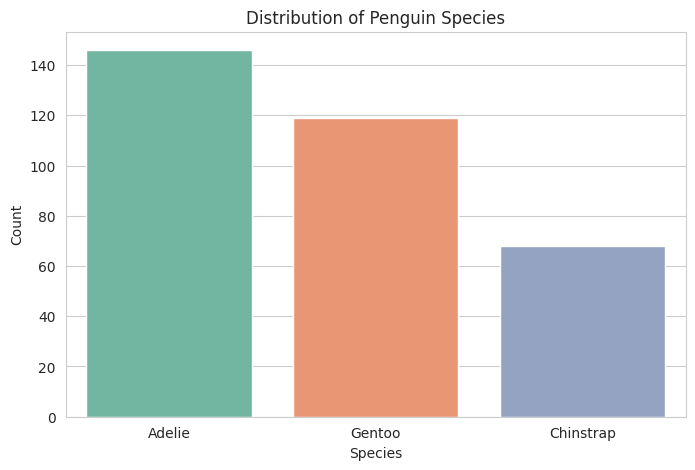

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=penguins,
    x="species",
    palette="Set2"
)

plt.title("Distribution of Penguin Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

Interpretation
* Adelie penguins are the most common species.
* Chinstrap penguins are the least common.
* The dataset is not perfectly balanced across species

7. Flipper Length vs Body Mass (Scatter Plot)

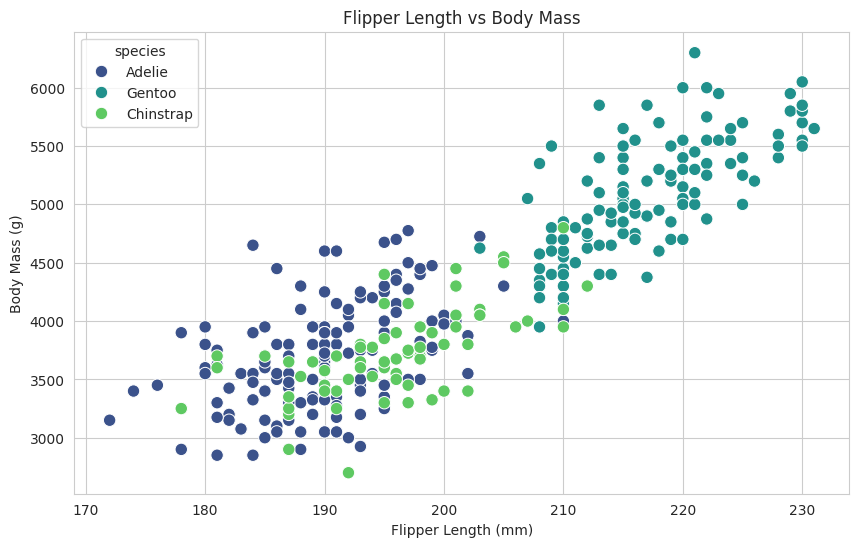

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    palette="viridis",
    s=80
)

plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")

plt.show()

Interpretation
* Strong positive relationship between flipper length and body mass.
* Gentoo penguins tend to be larger and heavier.
* Species form distinct clusters

8. Island Distribution (Pie Chart)

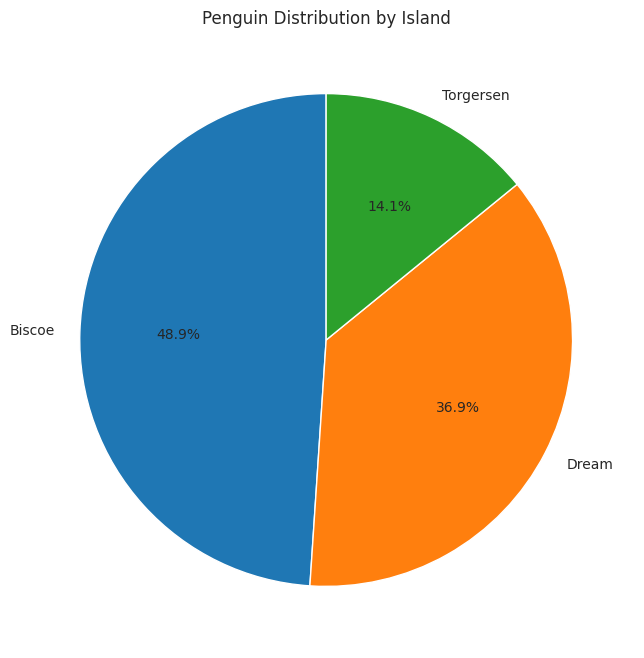

In [21]:
island_counts = penguins["island"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    island_counts,
    labels=island_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Penguin Distribution by Island")

plt.show()

Interpretation
* Most penguins come from Biscoe Island.
* Dream Island contributes a substantial portion.
* Torgersen contains the fewest penguins.

9. Sex Distribution Within Species

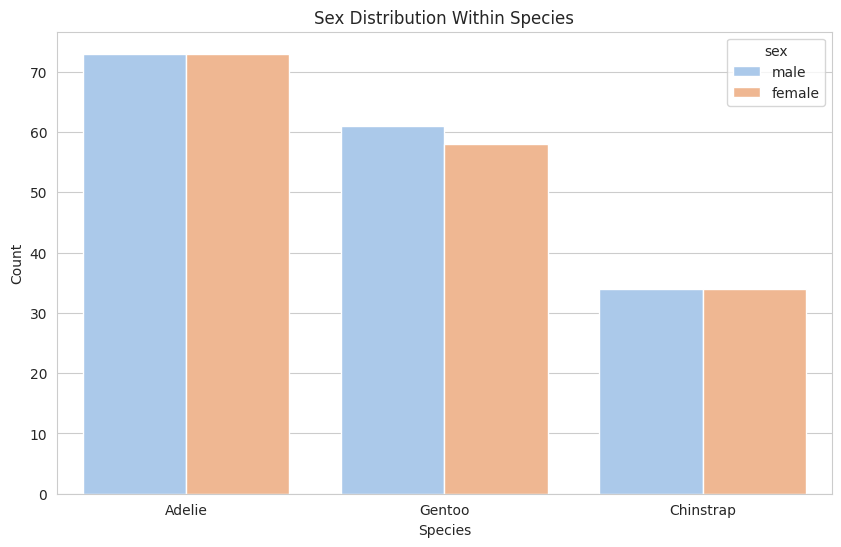

In [22]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=penguins,
    x="species",
    hue="sex",
    palette="pastel"
)

plt.title("Sex Distribution Within Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

Interpretation
* Male and female populations are relatively balanced.
* Small differences exist between species.

10. Correlation Heatmap

Select Numerical Features

In [23]:
numerical_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

In [24]:
corr = penguins[numerical_cols].corr()

Plot Heatmap

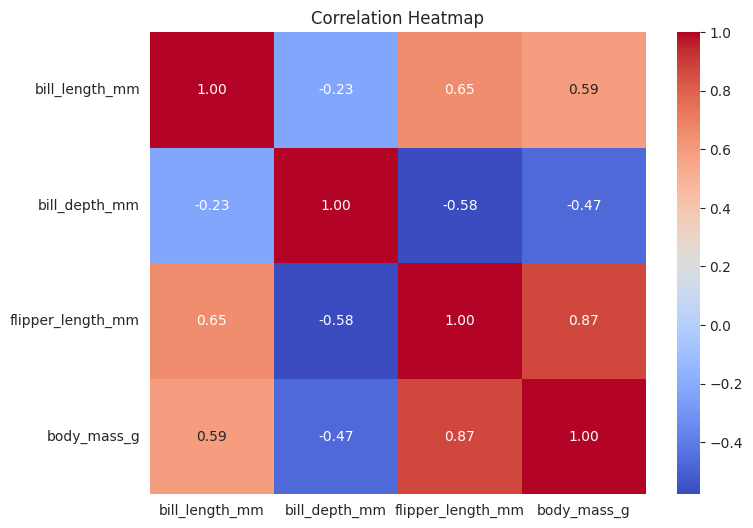

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Interpretation
* Flipper length and body mass show strong positive correlation.
* Bill depth and bill length have weaker relationships.
* Correlation helps identify important predictive variables.

11. Boxplots for Measurements by Species

Flipper Length

/tmp/ipykernel_17987/4076447313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


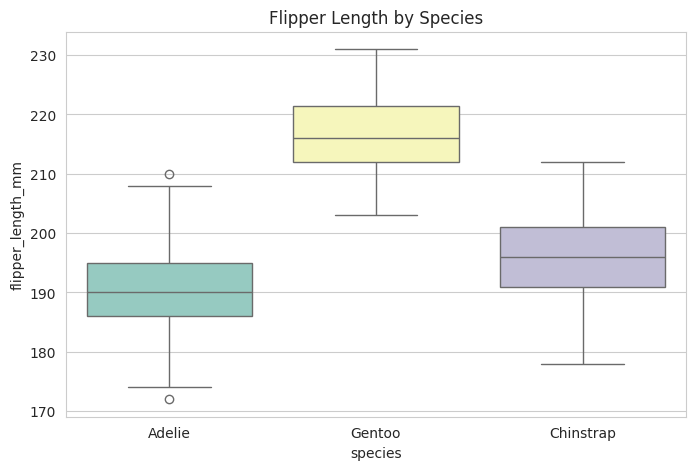

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=penguins,
    x="species",
    y="flipper_length_mm",
    palette="Set3"
)

plt.title("Flipper Length by Species")

plt.show()

Body Mass

/tmp/ipykernel_17987/3985407666.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


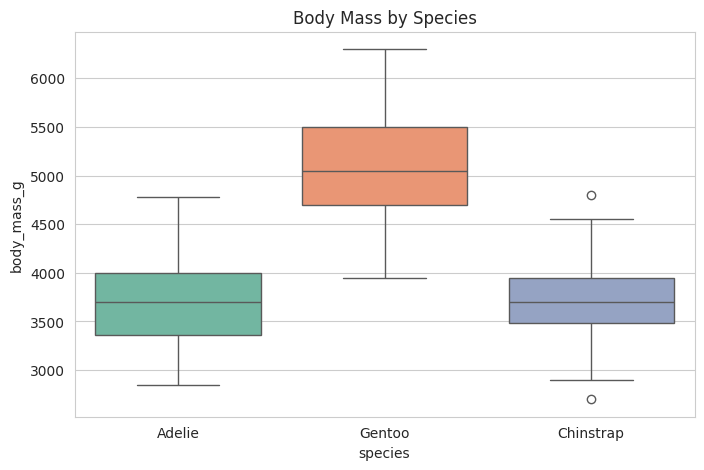

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    palette="Set2"
)

plt.title("Body Mass by Species")

plt.show()

Bill Length

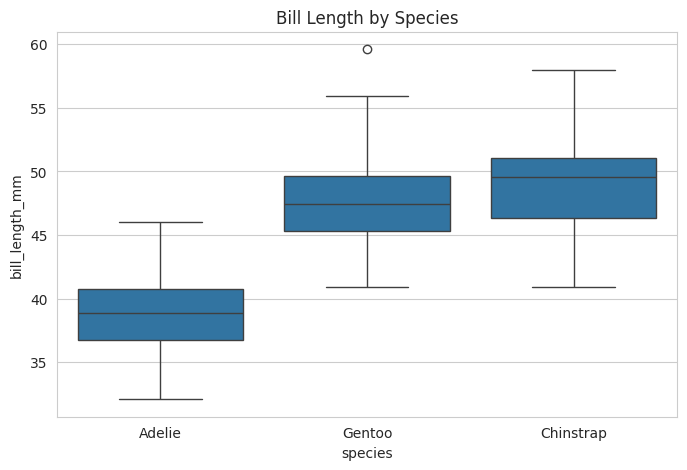

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=penguins,
    x="species",
    y="bill_length_mm"
)

plt.title("Bill Length by Species")

plt.show()

Interpretation
* Gentoo penguins generally have the highest body mass.
* Chinstrap penguins tend to have longer bills.
* Adelie penguins show smaller measurements overall.

12. Histograms of Measurements

Bill Length

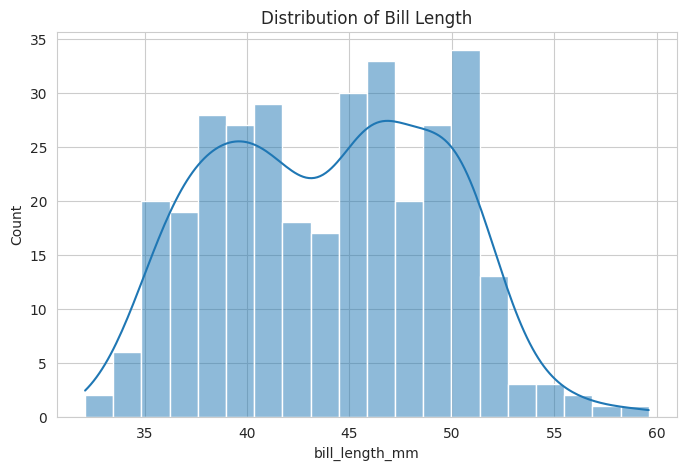

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    penguins["bill_length_mm"],
    bins=20,
    kde=True
)

plt.title("Distribution of Bill Length")

plt.show()

Bill Depth

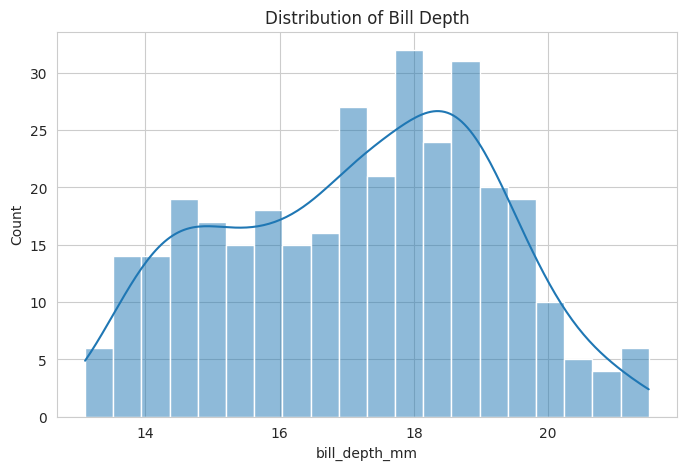

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    penguins["bill_depth_mm"],
    bins=20,
    kde=True
)

plt.title("Distribution of Bill Depth")

plt.show()

Flipper Length

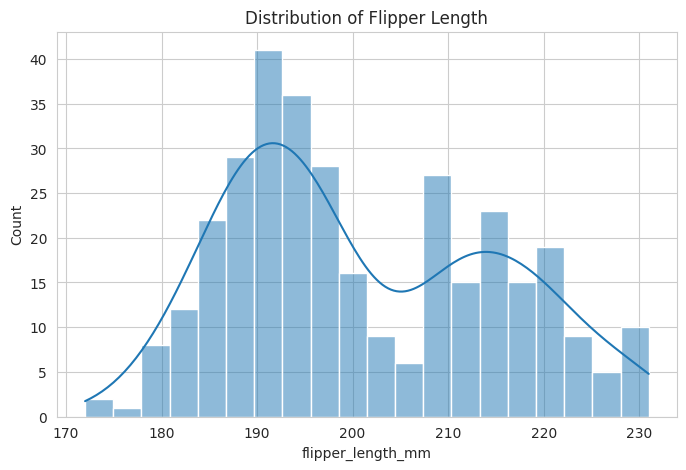

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    penguins["flipper_length_mm"],
    bins=20,
    kde=True
)

plt.title("Distribution of Flipper Length")

plt.show()

Interpretation
* Some distributions appear multimodal.
* Different species contribute to distinct peaks.

13. Combined Subplots

Compare multiple measurements simultaneously.

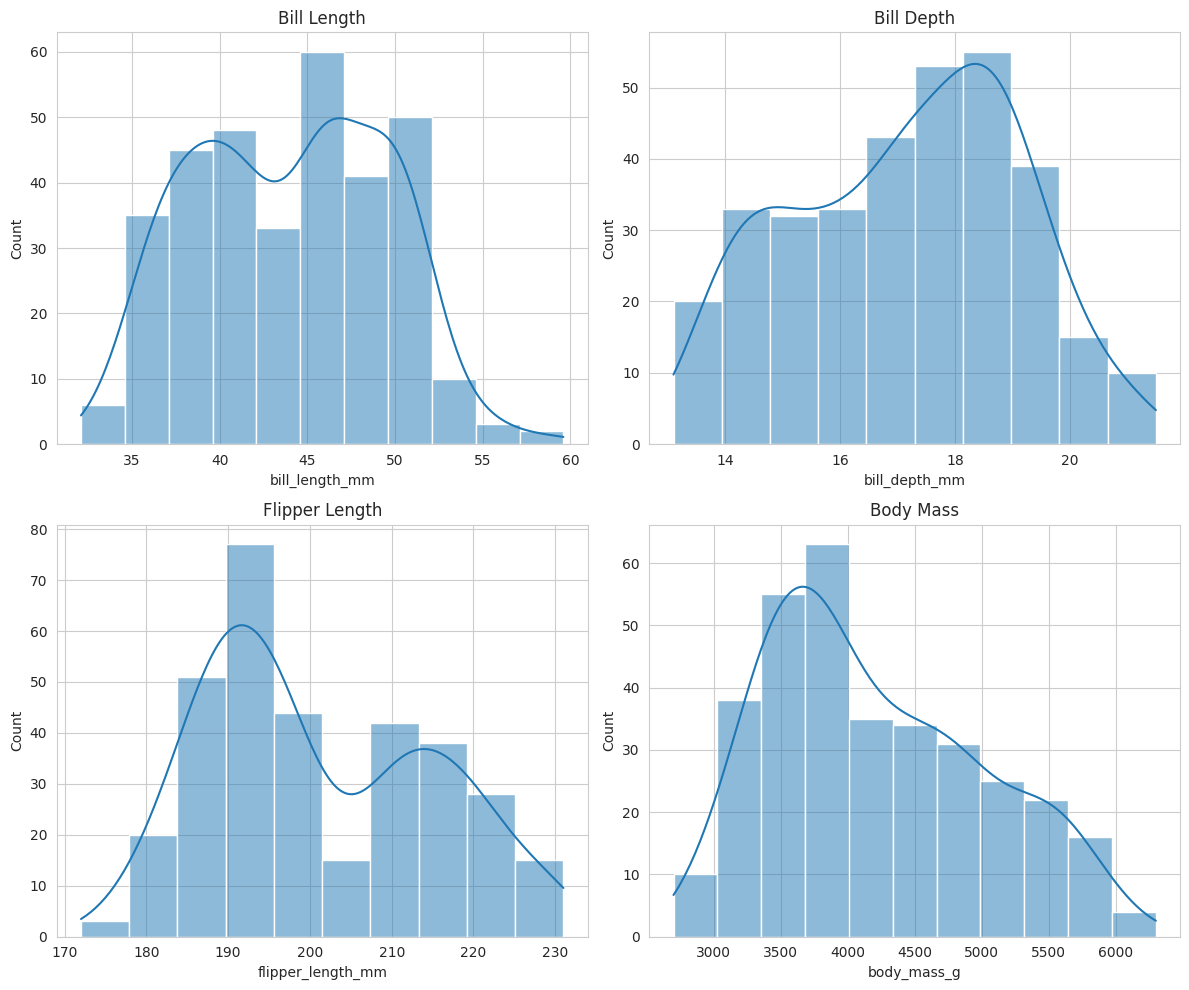

In [32]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

sns.histplot(
    penguins["bill_length_mm"],
    kde=True,
    ax=axes[0,0]
)

axes[0,0].set_title("Bill Length")

sns.histplot(
    penguins["bill_depth_mm"],
    kde=True,
    ax=axes[0,1]
)

axes[0,1].set_title("Bill Depth")

sns.histplot(
    penguins["flipper_length_mm"],
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Flipper Length")

sns.histplot(
    penguins["body_mass_g"],
    kde=True,
    ax=axes[1,1]
)

axes[1,1].set_title("Body Mass")

plt.tight_layout()
plt.show()

Interpretation

This layout makes it easier to compare all measurements simultaneously.

14. Pairplot

One of Seaborn's most powerful visualization tools.

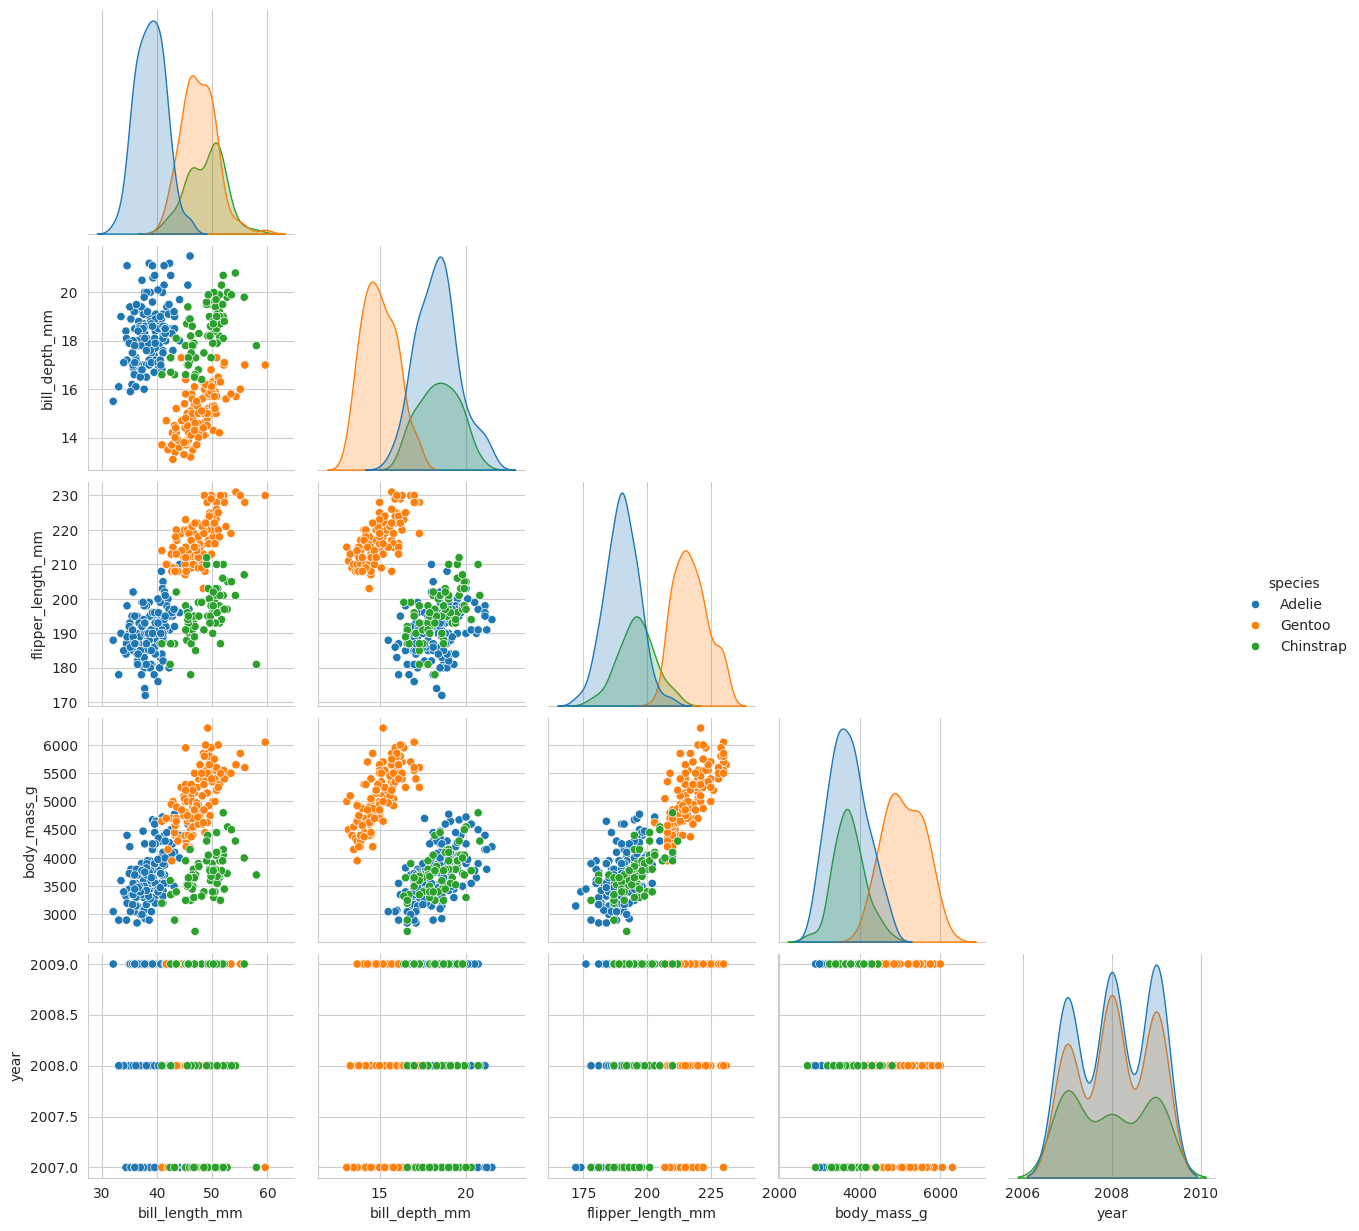

In [33]:
sns.pairplot(
    penguins,
    hue="species",
    corner=True
)

plt.show()

Interpretation

The pairplot reveals:

* Strong relationships among body measurements.
* Natural clustering by species.
* Gentoo penguins clearly separate from the other species.
* Species can almost be classified visually based on physical measurements.

15. Additional Visualization: Average Measurements by Species

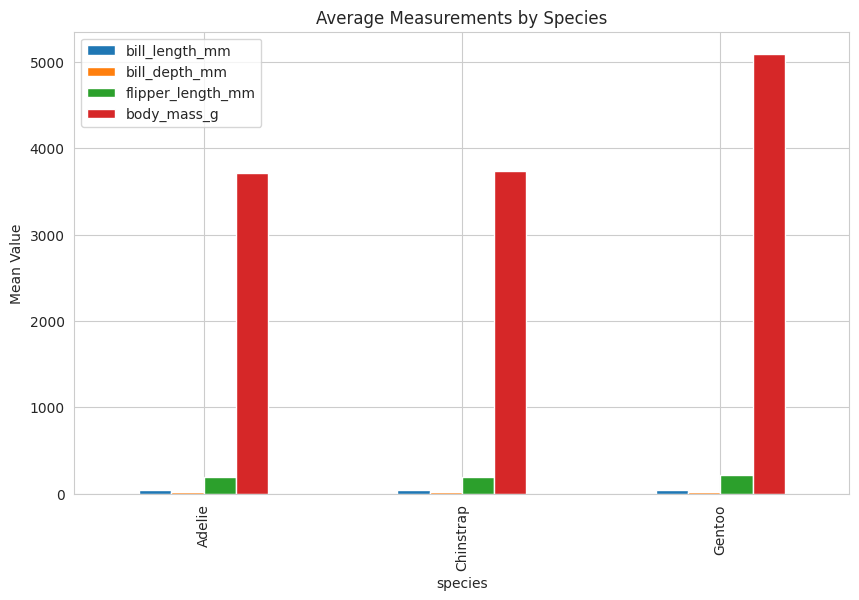

In [34]:
species_means = (
    penguins.groupby("species")
    [
        [
            "bill_length_mm",
            "bill_depth_mm",
            "flipper_length_mm",
            "body_mass_g"
        ]
    ]
    .mean()
)

species_means.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Measurements by Species")
plt.ylabel("Mean Value")

plt.show()

Interpretation

Provides a quick comparison of species characteristics.